/tmp/ipykernel_1658269/2798743612.py:301: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


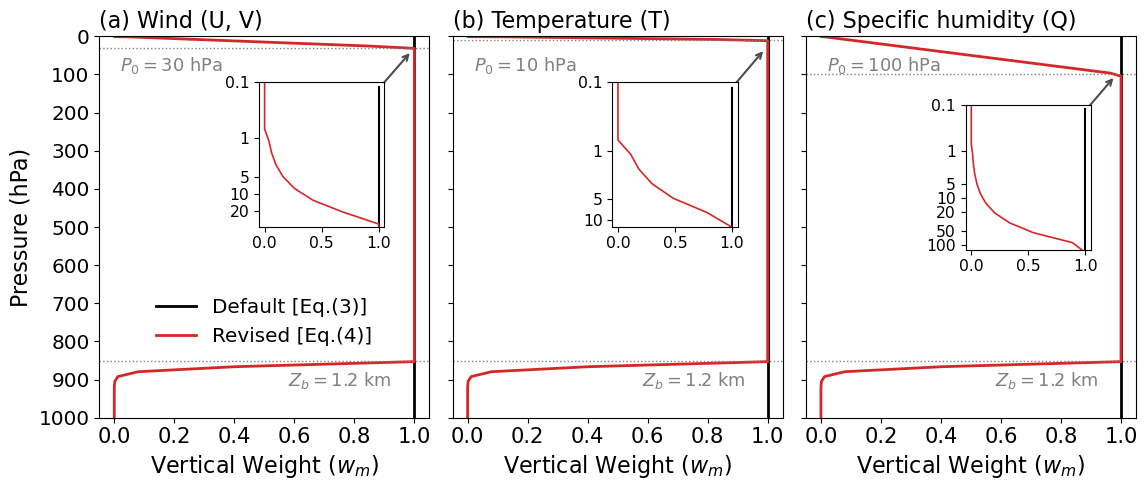

In [216]:
#!/usr/bin/env python3
"""
Schematic nudging weights on the E3SM hybrid-pressure grid
for (U,V), T, and Q, using different P0 for each variable.

Assumptions:
    Ps   = 1000 hPa (surface pressure)
    Zb   = 1.2 km   (PBL height)
    Tbar = 280 K    (standard atmosphere)

Vertical coordinate:
    p_m = (hyam + hybm) * Ps   (hybrid-pressure midpoints)

Weights:
    - Default:  w = 1
    - Modified: w_m(P,Z) as in Eq. (wm_variable)

Panels use:
    U/V: P0 = 30 hPa   (3000 Pa)
    T:   P0 = 10 hPa   (1000 Pa)
    Q:   P0 = 100 hPa  (10000 Pa)
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import LogLocator, LogFormatter

# -----------------------------
# Constants / user parameters
# -----------------------------
Ps_hpa    = 1000.0   # surface pressure (hPa)
P_top_hpa = 1.0      # top of nudging (hPa)
Zb_km     = 1.2      # PBL height (km)
Tbar_K    = 280.0    # standard atmosphere mean T (K)

Rd = 287.0           # J kg-1 K-1
g  = 9.81            # m s-2
H_km = (Rd * Tbar_K / g) / 1000.0  # scale height (km)

fontsize = 16

# P0 for each variable (converted from Pa to hPa)
P0_dict = {
    "Wind (U, V)":            3000.0 / 100.0,   # 30 hPa
    "Temperature (T)":        1000.0 / 100.0,   # 10 hPa
    "Specific humidity (Q)": 10000.0 / 100.0,   # 100 hPa
}

# -----------------------------
# Hybrid coefficients (midpoints)
# -----------------------------
hyam = np.array([
    0.000123825413055617, 0.000182829235506849, 0.000269948862120937,
    0.000398581703622882, 0.000588509146564753, 0.0008689385700405,
    0.00128299490825493, 0.00189435247940639, 0.00279702693529326,
    0.00412983315502484, 0.00596844936711808, 0.00837740437894177,
    0.0114737872305346, 0.0153339382222169, 0.0199963379781671,
    0.0254446965099616, 0.0315932512912852, 0.038366283094427,
    0.0456711979394268, 0.0533095614343925, 0.0610151816703695,
    0.0684763902297126, 0.075355335897261, 0.0819462751247347,
    0.0889105431495609, 0.096466673444937, 0.104664967286755,
    0.113560001421463, 0.123210991427466, 0.133682179932106,
    0.1450432655327, 0.157369877840079, 0.170744079521582,
    0.178544787903854, 0.1775308746758, 0.173663333437495,
    0.16946709965782, 0.164914245512286, 0.159974463267925,
    0.154614872717868, 0.148799804140909, 0.142490535438863,
    0.13564505757417, 0.128217812275819, 0.12015936434857,
    0.111539324098064, 0.102670630107687, 0.0938439551103799,
    0.0852361112323467, 0.0769322627201163, 0.0689676092371833,
    0.0614493198709789, 0.05448265000188, 0.0481685284230159,
    0.0426011286344556, 0.0378655212834811, 0.0339653047149139,
    0.0306674030235009, 0.0276074433039125, 0.0246201492984213,
    0.0217103132502219, 0.0188826608259991, 0.0161418125936294,
    0.0134923049370923, 0.0109385772281658, 0.00848494101951357,
    0.0061355704048767, 0.00389449072883921, 0.0017655681028817,
    0.000364808451654059, 0.0, 0.0
])

hybm = np.array([
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.00671011432529713, 0.0234680651953042, 0.0444176635955054,
    0.0671476869296703, 0.0918094403929732, 0.118567095041909,
    0.147598767404014, 0.179097701948261, 0.213273593999517,
    0.250353966345741, 0.290585650603444, 0.334236449640608,
    0.380929249924463, 0.428968901249776, 0.476780947992953,
    0.523407663189237, 0.568387705241455, 0.611530435201057,
    0.652255318449455, 0.689992179321315, 0.724194309520338,
    0.75435162108428, 0.780003302193755, 0.801129866171697,
    0.818993846087094, 0.835568982345428, 0.851750499035683,
    0.867512422846049, 0.882829172464221, 0.897675691826778,
    0.912027443210243, 0.925860417594538, 0.939151217834863,
    0.951877195966462, 0.964016589671936, 0.975548495766603,
    0.985840524709414, 0.993756956304222, 0.998496439491762
])

# -----------------------------
# Hybrid pressures and diagnosed heights
# -----------------------------
nlev = min(len(hyam), len(hybm))
A = hyam[:nlev]
B = hybm[:nlev]

P_raw = (A + B) * Ps_hpa  # hPa
P_raw = P_raw[P_raw > 0.0]
P_hpa = np.sort(P_raw)[::-1]  # surface → top

# diagnose geometric height using standard atmosphere
# P = Ps * exp(-Z/H) => Z = -H * ln(P/Ps)
Z_km = -H_km * np.log(P_hpa / Ps_hpa)

# PBL pressure for annotation
P_Zb = Ps_hpa * np.exp(-Zb_km / H_km)

# -----------------------------
# Weight functions
# -----------------------------
def w_default(P):
    """Default EAMv2: full nudging everywhere."""
    return np.ones_like(P)

def w_m(P, Z, P0, P_top=P_top_hpa, Zb=Zb_km):
    """
    Combined vertical weight w_m(P,Z):

      - P <= P_top:                0
      - P_top < P <= P0:           P / P0
      - P > P0 and Z <= Zb:        0.5 * [1 + tanh((Z - Zb)/(0.1*Zb))]
      - otherwise:                 1
    """
    w = np.ones_like(P)

    # top cut-off
    w[P <= P_top] = 0.0

    # upper ramp
    mask_ramp = (P > P_top) & (P <= P0)
    w[mask_ramp] = P[mask_ramp] / P0

    # PBL taper
    mask_pbl = (P > P0) & (Z <= Zb)
    w[mask_pbl] = 0.5 * (1.0 + np.tanh((Z[mask_pbl] - Zb) / (0.1 * Zb)))

    return w

w_def = w_default(P_hpa)

# -----------------------------
# Plot: 3 panels (U/V, T, Q)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

# y-axis ticks (linear here; could also be used with log)
yticks = [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100, 0]
panel_labels = ["(a)", "(b)", "(c)"]

for i, (ax, (title, P0)) in enumerate(zip(axes, P0_dict.items())):
    w_mod = w_m(P_hpa, Z_km, P0=P0)

    ax.plot(w_def, P_hpa, label="Default [Eq.(3)]",
            color="black", linewidth=2, linestyle="-", alpha=1.0)
    ax.plot(w_mod, P_hpa, label="Revised [Eq.(4)]",
            color="tab:red", linewidth=2)

    ax.set_title(f"{panel_labels[i]} {title}", fontsize=fontsize, loc="left")
    ax.set_xlabel("Vertical Weight ($w_m$)", fontsize=fontsize)
    ax.set_xbound(-0.05, 1.05)
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

    # vertical axis
    ax.invert_yaxis()
    ax.set_ylim(Ps_hpa, 0)
    ax.set_yticks(yticks)

    if i == 0:
        # LEFT PANEL: force tick labels to be shown
        ax.set_ylabel("Pressure (hPa)", fontsize=fontsize)
        ax.set_yticklabels(yticks, fontsize=fontsize*0.9)
        ax.tick_params(axis="y", which="both", labelleft=True)
    else:
        # other panels: no numeric labels on y
        ax.set_yticklabels([])

    # annotate P0 and Zb as before
    ax.axhline(P0, linestyle=":", color="grey", linewidth=1)
    ax.text(0.02, 90, fr"$P_0 = {P0:.0f}$ hPa",
            fontsize=fontsize*0.8, color="grey")

    ax.axhline(P_Zb * 0.986, linestyle=":", color="grey", linewidth=1.0)
    ax.text(0.58, P_Zb * 1.06,
            fr"$Z_b = {Zb_km:.1f}$ km",
            fontsize=fontsize*0.8, color="grey")
    
    ax.tick_params(labelsize=fontsize * 0.95)

    # -----------------------------
    # Inset: zoom upper atmosphere
    # -----------------------------
    if i == 0:
        x1 = 0.45
        y1 = -0.09
        xx = 1.0
        yy = P0
        xt = 5
        yt = 5
    elif i == 1:
        x1 = 0.45
        y1 = -0.09
        xx = 1.0
        yy = P0+15
        xt = 5
        yt = 5
    else:
        x1 = 0.45
        y1 = -0.15
        xx = 1.05
        yy = P0-60
        xt = 25
        yt = 25
        
    inset = inset_axes(
        ax,
        width="38%", height="38%",
        loc="upper left",
        bbox_to_anchor=(x1,y1, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0.8
    )
    
    inset.plot(w_def, P_hpa, color="black", linewidth=1.5)
    #inset.plot(w_mod, P_hpa, color="tab:red", linewidth=1.5)

    # fine pressure grid for inset smoothing (log spaced)
    P_fine = np.logspace(np.log10(0.1), np.log10(Ps_hpa), 20)
    
    Z_fine = -H_km * np.log(P_fine / Ps_hpa)
    w_mod_fine = w_m(P_fine, Z_fine, P0=P0)
    
    # inset plot (replace w_mod -> w_mod_fine and P_hpa -> P_fine)
    inset.plot(w_mod_fine, P_fine, color="tab:red", linewidth=1.2)

    inset.set_yscale("log")
    inset.invert_yaxis()
    
    # Only show region ABOVE P0 (smaller pressures)
    p_low  = P0 * 1.25
    p_high = 0.1
    inset.set_ylim(p_low, p_high)
    
    # ----- nicer log ticks -----
    # Major ticks at 10^2, 10^1, 10^0, 10^-1 ...
    inset.yaxis.set_major_locator(LogLocator(base=10.0))
    inset.yaxis.set_major_formatter(LogFormatter(base=10.0))
    
    # Turn off (or soften) minor ticks to keep it uncluttered
    inset.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))
    # inset.tick_params(which="minor", length=0)   # (optional)

    # ticks just within that region
    yticks_inset = [p for p in [100, 50, 20, 10, 5, 1, 0.1]
                    if p <= P0 and p >= 0.1]
    inset.set_yticks(yticks_inset)
    inset.set_yticklabels([str(v) for v in yticks_inset],
                          fontsize=fontsize * 0.8)

    inset.set_xlim(-0.05, 1.05)
    inset.set_xticks([0.0, 0.5, 1.0])
    inset.tick_params(labelsize=fontsize * 0.7)
        
    ax.annotate(
        '',
        xy=(xx,yy), 
        xycoords=ax.transData,
        xytext=(0.5, 0.5), 
        textcoords=inset.transAxes,
        arrowprops=dict(
            arrowstyle='->', 
            linewidth=1.5, 
            color='0.3',
            shrinkA=xt, 
            shrinkB=yt
        ),
    )

    
axes[0].set_ylabel("Pressure (hPa)", fontsize=fontsize)
axes[0].set_yticks(yticks)
axes[0].set_yticklabels(yticks, fontsize=fontsize*0.9)
axes[0].tick_params(axis="y", which="both", labelleft=True)

# legend + layout
axes[0].legend(
    loc="center",
    bbox_to_anchor=(0.5, 0.25),   # (x, y) in axes fraction — lower y to move down
    frameon=False,
    fontsize=fontsize*0.9
)

plt.tight_layout()
plt.subplots_adjust(left=0.12)  # make sure labels are not clipped
# --- Save figure ---
fig.savefig("nudging_weights_UVTQ.pdf", dpi=600, bbox_inches="tight")

plt.show()
plt.show()
